# Module 3 NetworkX Tutorial


In this Tutorial, we will examine how to use several of the NetworkX Graph generation models which will be relevant for this week's assignment.

# The Erdos Renyi Graph:

Generating this is quite simple. Lets say we want to have a graph `G` where we have 10 nodes, and each edge has a 50% chance of existing. We can use the `nx.erdos_renyi_graph` function below with n=10 and p=0.50 to generate this graph.

NOTE: When generating all graphs in this tutorial and assignment, we will always use seed=42 for the sake of consistency.

In [1]:
import networkx as nx

G = nx.erdos_renyi_graph(n=10, p=50/100, seed=42)

# We can do all normal graph operations now, like getting the number of edges, nodes, etc.
num_edges = G.number_of_edges()
print(num_edges)

21


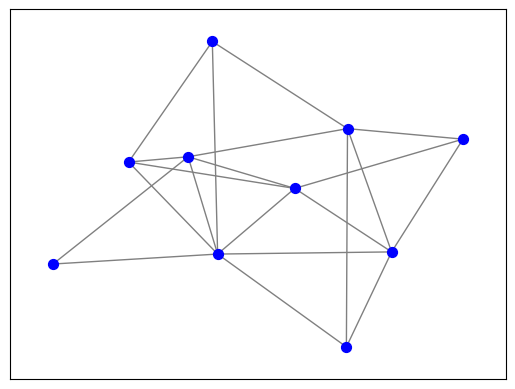

In [2]:
#Visualize the resulting graph
nx.draw_networkx(G, pos=nx.spring_layout(G), with_labels=False, node_color='blue', 
                 edge_color='grey', node_size=50)

# The Stochastic Block Model

The Stochastic Block Model (SBM) is a type of random graph model used to generate networks with a specified community structure. It divides nodes into blocks (or communities) and controls the probability of edges within and between these blocks.

Let's create a simple SBM graph. First, we'll define two communities of size 10:

In [3]:
community_sizes = [10, 10]  

Now, we need to define a probability matrix for the graph generation. This matrix will be of dimensions n * n, as each community will have a probability defined for generating edges between every community, including itself. Let's create an example below:

In [4]:

edge_probability_matrix = [
        [0.6, 0.05],  # Probabilities within and between communities
        [0.05, 0.5],

    ]

So above, the element at [0][0], 0.6 is the probability of a possible edge forming between a node in community 0 and another node in community 0 - in this case, an intracommunity edge! So for this graph, community 0 has each of its intracommunity edges exist with a 60% chance.

The element at [0][1] however, 0.05, is the probability of a possible edge between a node in community 0 and a node in community 1 existing, being a 5% chance of this intercommunity edge existing!

Now, lets plug this all into the graph generation and take a look at the resulting graph!

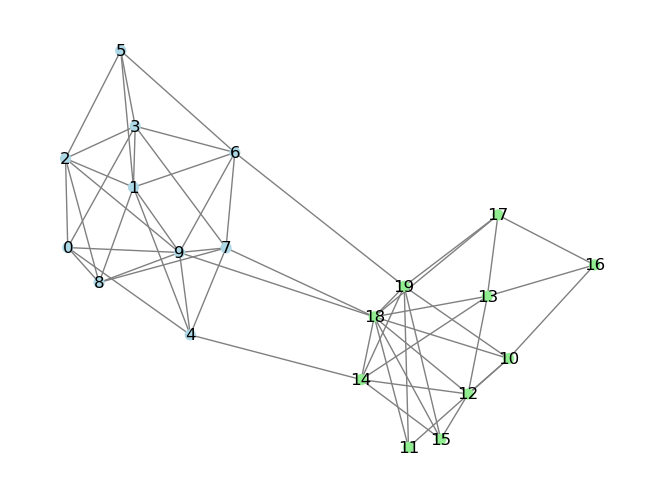

In [5]:
G_Stochastic = nx.stochastic_block_model(community_sizes, edge_probability_matrix, seed=42)

# Draw the graph
pos = nx.spring_layout(G_Stochastic, seed=42)  
colors = ['lightblue' if G_Stochastic.nodes[node]['block'] == 0 else 'lightgreen' for node in G_Stochastic.nodes]
nx.draw(G_Stochastic, pos, node_color=colors, with_labels=True, node_size=50, edge_color='gray')


# The Configuration Model

The last graph generation model we will examine is the Configuration Model. In this model, each node has a predefined number of edges coming out of it.

Let's create an example graph. First, let's define the degree for each node:



In [6]:
#Node 0 will have a degree of 3, node 1 a degree of 2, etc.

degree_sequence = [3, 2, 2, 1, 1, 1]

Now, we can generate the graph. Take a look at the resulting graph, and we can see that the corresponding degrees are there.

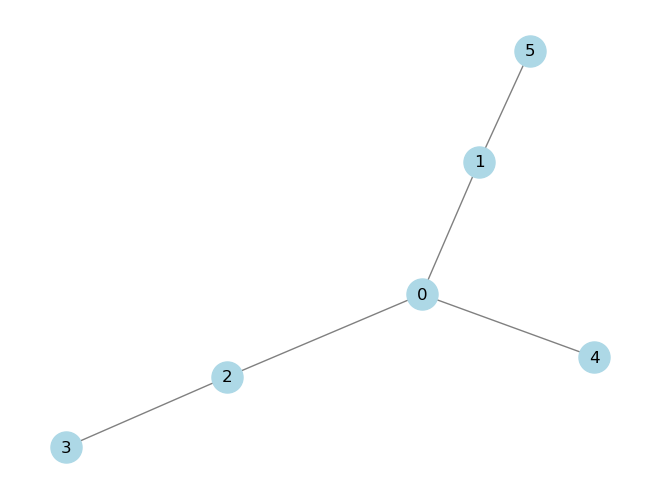

In [7]:
G_config = nx.configuration_model(degree_sequence, seed=42)

pos = nx.spring_layout(G_config, seed=42)  # Layout for visualization
nx.draw(G_config, pos, with_labels=True, node_size=500, node_color='lightblue', edge_color='gray')